In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#***WEB SCRAPING***
import requests
import pandas as pd
import time

def scrape_fashionphile_entire_site():
    master_list = []

    api_url = "https://nsjaz0qg7k-dsn.algolia.net/1/indexes/*/queries"
    params = {
        "x-algolia-agent": "Algolia for JavaScript (4.20.0)",
        "x-algolia-api-key": "e545a3cf82cf7dbc5ff39f49c214863e",
        "x-algolia-application-id": "NSJAZ0QG7K"
    }

    current_page = 0
    total_pages = 1

    while current_page < total_pages:
        payload = {
            "requests": [
                {
                    "indexName": "shopify_products_published_at_desc",
                    "params": f"query=&hitsPerPage=1000&page={current_page}"
                }
            ]
        }

        response = requests.post(api_url, params=params, json=payload)

        if response.status_code == 200:
            data = response.json()
            results = data['results'][0]

            # Sync total_pages with the actual API limit
            total_pages = results.get('nbPages', 0)
            hits = results.get('hits', [])
            master_list.extend(hits)

            current_page += 1
            # Small sleep to be polite to the server
            time.sleep(1)
        else:
            print(f"Request failed: {response.status_code}")
            break

    return pd.DataFrame(master_list)

df = scrape_fashionphile_entire_site()
file_path = '/content/drive/My Drive/handbag_valuation_SCRAPED.csv'
df.to_csv(file_path,index=False)


In [3]:
#***RECENT DATA SET PREPARATION & APPEND TO HISTORICAL DATA***
import pandas as pd
import numpy as np
import ast

#1. Select only relevant columns
recent = pd.read_csv('/content/drive/My Drive/handbag_valuation_SCRAPED.csv')
raw_df = recent[['id','vendor','title', 'price', 'product_type','meta']]
#raw_df.info()

#2. Create quality report
def data_quality_check(raw_df):
  quality_report = {
      'total_records': len(raw_df),
      'duplicate_rows': int(raw_df.duplicated().sum()),
      'missing_values': raw_df.isnull().sum().to_dict(),
      'invalid_vendor': raw_df[raw_df['vendor'] == "FASHIONPHILE"].shape[0],
      'invalid_type': raw_df[raw_df['product_type'] != "Bags"].shape[0],
      'invalid_price': raw_df[raw_df['price'] <0].shape[0]
      }
  return quality_report
quality_report = data_quality_check(raw_df)
#print(quality_report)

#3. Remove duplicate records
df_deduped = raw_df.drop_duplicates(subset=['id'])
#df_deduped.shape

#Step 3: Identify & address null / NA values (remove vs. impute/fill)

#Step 4: Identify & address outliars or invalid records
vendor_condition = df_deduped['vendor'] != "Fashionphile"
product_condition = df_deduped['product_type'] == "Bags"
price_condition = df_deduped['price'] > 0
filtered = df_deduped[vendor_condition & product_condition & price_condition]
new_field = filtered.copy()
#print(len(filtered))

#Step 5: Create any new fields
new_field["meta"] = new_field["meta"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
additional_fields = pd.json_normalize(new_field["meta"], sep=",")
#print(additional_fields.info())

additional_for_merge = additional_fields[['custom,condition','custom,filters_color', 'custom,filters_material','custom,retail_savings',
                                         'swym_wishlist,wishlist_social_count']]
#print(additional_for_merge.info())

merge = pd.concat(
    [filtered.reset_index(drop=True),
     additional_for_merge.reset_index(drop=True)], axis=1
).drop(columns=['meta', 'product_type'])
#print(merge.info())

#Step 6: Rename columns & save file
renamed = merge.rename(columns= {'custom,condition':'condition', 'custom,filters_color': 'color', 'custom,filters_material': 'material',
                                 'custom,retail_savings':'retail_savings','swym_wishlist,wishlist_social_count':'num_wish_list'})

#Step 8: Append to historical file
historical = pd.read_csv('/content/drive/My Drive/handbag_valuation_HISTORICAL.csv')
print(historical.info)
combined_all = pd.concat([historical, renamed],ignore_index=True)
combined = combined_all.drop_duplicates(subset=['id'])
file_path = '/content/drive/My Drive/handbag_valuation_HISTORICAL.csv'
combined.to_csv(file_path,index=False)


<bound method DataFrame.info of                    id         vendor  \
0      12705845018927         Hermes   
1      12705844822319  Louis Vuitton   
2      12705834959151  Louis Vuitton   
3      12705824801071  Louis Vuitton   
4      12705824506159  Louis Vuitton   
...               ...            ...   
25314  15578335150383  Louis Vuitton   
25315  15578332004655  Saint Laurent   
25316  15578327580975         Chanel   
25317  15578312966447         Hermes   
25318  15578309427503         Chanel   

                                                   title    price   condition  \
0      Shiny Niloticus Crocodile Constance Elan 25 Ro...  18545.0   Excellent   
1                                   Monogram Mini Bumbag   2280.0   Excellent   
2                                  Damier Ebene Berkeley   1375.0  Shows Wear   
3       Taurillon Capucines BB Scarabeo Iridescent Black   4505.0  Shows Wear   
4               Empreinte Monogram Giant LV Bundle Cream   2965.0   Excellent   
.

In [13]:

#***CREATE NEW FEATURE MODEL_NAME***
import pandas as pd
import numpy as np
import re
import unicodedata

historical = pd.read_csv('/content/drive/My Drive/handbag_valuation_HISTORICAL.csv',index_col=0)
#print(len(historical))

#Step 1. Identify top 10 brands with bags >$1500 to filter
#print(historical['vendor'].value_counts().head(10))
top_brands = ['Louis Vuitton','Chanel','Gucci','Hermes','Saint Laurent','Christian Dior','Bottega Veneta','Celine','Fendi','Prada']
df_all = historical[historical['vendor'].isin(top_brands)].copy()
df_all['model_name'] = None
df_all['model_name'] = df_all['model_name'].astype(object)
df = df_all[df_all['price']>1500]
df = df.copy()

#Step 2. Create mapping for "title" field to identify specific bag model (model_name)
vendor_model_map = {
    'Louis Vuitton': ['Neverfull','Speedy','Alma','Noe','Keepall','Pochette','Bumbag','Bum Bag','Capucine','OnTheGo','Odeon', 'All In', 'All-In',
                      'Papillon','Looping','Twist','Dauphine','Carryall','Metis','Montaigne','Berkeley','Palm Springs','Vanity',
                      'Cluny','Side Trunk','Vendome','Siena','Neonoe','Artsy','Loop Hobo','Aubagne','Cruiser','Rivoli','Hudons',
                      'Favorite','Venus','Hyde Park','Graceful','Cannes','Horizon','Sac Plat','On My Side','Flore','Petite Malle',
                      'Coussin','Atlantis','Baia','Go-14','Luco','Soho','Why Knot','Clapton','Turenne','Pleaty','Petit Palais',
                      'Neo Cabby','Tivoli','Trunk','Galliera','Croisette','Georges','Eva','Sunset','Totally','Trocadero','Verona',
                      'Chelsea','Locky','Lockit','Hudson','Pegase','Babylone','Boulogne','Croissant','Hobo','Tournelle','Chapeau Souple',
                      'Saumur','Slouchy','Popincourt','Idiole','Lorette','Diane','Surene','Idole','Spring Street','Girolata','New Wave',
                      'Iena','Over the Moon','Freedom','Vavin','Saint Placide','Nil','Sling','Buci','Pont 9','Boite','Deauville','Victoire',
                      'Linda','Everyday','South Bank','Marelle','Love Note','Judy','Santa Monica','Sologne','Double V','Valisette','Game On',
                      "Rendez-vous",'Camera','Very One','Mabillon','Ever Mini','Marceau','NéoNoé','Montsouris','Selene','Muria',
                      'Toupie','Delightful','Vaugirard','Porte-Documents','Eole','Pallas','Tilsitt','Passy','Steamer','Hina','Vivacite',
                      'Baggy','Greta','Drop','Gracie','Tuileries','Trio Mini','Roadster','District','Biface','Boursicot','Kensington',
                      'Wynwood','Griet','Marais','Bundle','Madeleine','Grand Palais','Loop','Bagatelle','Melie','Blance','Saint Germain',
                      'Blanche','Pouch on Strap','Cite','Solo','Again','Bel Air','Portobello','Vive','Twice','Soufflot','Sully','Evora',
                      'Antheia','Bond Street','Marignan','Icare','Veau Cachemire','Trevi','Berri','Fold Me','Lockme','Triangle','Bento',
                      'Beaubourg','Utility','Cherrywood','Annie','Pop my heart','Felicie','Around Me','Beverly','Carry It','Coffret Joaillerie',
                      'Eden','Fan','Kirsten','Marilyn','Dora','Theda','Lys','Rose Des Vents','Motard','Hamac','Pouch','Bloomsbury',
                      'Trouville','Eliza','Trianon','Sharleen','Catchy','Express','Cabas','Gaia','Rita','Twinny','Retiro','Maida',
                      'Sac Sport','Raye Port','Biker','Palermo','Musette','All Day','Ellipse','Piano','Boetie','Riverside','Noé',
                      'Upside Down','Carry All','Propriano','Catogram','Phenix','Tyler the Creator','Tambourin','Duck','OnThegGo',
                      'Courtney','Lineup','Grenelle','Patti','Lodge','Saint Cloud','Ever More','Polochon', 'Zephyr','Golf','East West',
                      'Glasses','Spontini','Saintonge','Odyssee','Quartz','Cherry Blossom','Lymington','Ribera','Fleur De Jais','Square',
                      'Coffret','Travel Bag','Moon','No Way','Belmont','Bastille','Arizona','Audra','Chrissie','Cookie','Marellini',
                      'Milla','Beaumarchais','Eye Miss You','Chantilly','Brittany',
                      'Messenger','Duffle Bag','Backpack','Bucket','Tote','Clutch','Wallet','Chain','Phone','Briefcase','Carrier'],
    'Chanel': ['Flap','Top Handle','Boy','Gabrielle','Vanity','Chanel 19','Chanel 25','Chanel 22','Deauville','Bowling','Bowler',
               'Shopping Tote','Timeless','Timeless Clutch','Cambon','PTT','11.12',' Love Heart','Kelly','Hobo',
               'Yours Buttons','Medallion','Messenger','Cerf','Plexiglass','2.55','Mood','My Crush','Frame', 'CC Shoulder', 'Chocolate Bar',
               'Clutch','Evening Bag','Coco Click','Coco Shoulder','All Day Long','Bow','Trunk','Lifesaver','Just Mademoiselle',
               'Crossbody','Small Box','Drawstring','Shopping Bag','Wallet','Camera','Backpack','Belt Bag','Waist Bag','Bucket Bag',
               'Phone', 'Glasses','Card','Garment','Purse with Chain','Pouch','Lipstick','Olsen','CC Heart','Symbols','31','Popcorn',
               'Ballerina','Saddle','Pochette','Box','Hoop','Slot Machine','Side Pack','Framing','Shearling', 'Carrying',
               'Rescue Wheel','Korean',
               'Quilted Shoulder','Caviar Shoulder','Laptop','Tote','Shopping','Shoulder Bag','Toiletry','Duffle','Weekender'],
    'Gucci':['Jackie','GG Marmont','Bamboo','Dionysus','Diana','Horsebit','Ophidia','Mercato','GG Emblem','Soho','Luce','Web','Dome',
             'Blondie','Giglio','Aphrodite','Padlock','Messenger','Joy','Abbey','Guccissima','GG Supreme','Sylvie','Boat','Interlocking G',
             'Lovely Heart','Zumi','Pop','Totissima','Running','Off the Grid','Rajah','Margaret',r"Re\(Belle\)",'Maxi B','Petite GG','Brera',
             'Globe-trotter','Thiara','Wallet on Chain','Ottilia','Arabella', 'Trolley','Mini Chain','Mini Heart','Chain Handbag',
             'Dahlia', 'Beauty Case','Belt Bag','Shoulder Bag','Backpack','Duffle','Crossbody','Tote'],
    'Hermes': ['Birkin','Kelly','Constance','Picotin','Evelyne','Herbag','Lindy','Halzan','Vespa','Steve','Silkycity',
               'Garden','Bolide','Tablier','Jypsiere', 'Collier de Chien','Rodeo','Valparaiso','Horizontal','Toolbox','Roulis',
               'Fourre Tout','Cityslide','Herline','Geta','Elan','Della',"In-the-Loop", 'Hac a Dos','Beach Bag','Plume',"R.M.S",
               'Double Sens','Cavaliere','Videpoches','Verrou','Wallet','Card Holder','Whitebus','Faubourg','Sac De Pansage','2002 20',
               'Arcon','Arçon','24/24','Jige','Victoria','Convoyeur','Cabasellier','Medor','White Bus','Steeple','Trim Duo', 'Luggage',
               'Good News','Trim','Biais','Clemence','Gallop','Fishing Bag','Licol','Aline','Egee','Petite Course',
               'Saut','Sailor','Maximors','Citynews','Sac Catenina','Zipengo','Bitter Apple'],
    'Saint Laurent': ['Sac de Jour','Loulou','Lou','Manhattan','Rive Gauche','Kate','Lou Camera','Sunset','Niki','Hobo',
                      'Jamie','Bea','Nolita','West Hollywood','Icare','Uptown','Cassandre','Cassandra','Envelope','Triquilt', 'Tribute',
                      'Kaia','Oxalis','Classic Y','Universite','June Box','Teddy','Cabas','Vanity','Le 37','Le 61','Muse','College',
                      'Calypso','Solferino','Le Monogramme','Voltaire','Take Away','5 A 7','Icarino','Carre','Vicky',
                      'Chain Wallet','Compact Wallet','Tote','Duffle','Belt Bag','Travel','Shoulder Bag', 'Backpack','Satchel','Shopping Bag',
                      'Bucket','Camera','Le Fermoir'],
    'Christian Dior': ['Lady Dior','Saddle','Book Tote','Montaigne','Caro','D-Joy','D-Lite','Diorama','Bobby','Diorstar','J\'Adior',
                       'Groove','Lady 95','Trotter','Boston',r"dio\(r\)evolution",'Toujours','Open Bar','Gallop','Talk Phone','Roller Messenger',
                       'Rimowa','Clutch','D-Vibe','Dioraddict','Bow','Diortravel','Dioramour','Jolie','My Dior','East West','Miss Dior',r"C'est",
                       'Diorissimo','Ammi','Catherine','D-Motion','Club','Diorcamp','Evening','Voyage', 'Columbus','D-Journey','Kids', 'Scarab',
                       'Macrocannage', 'Weekender','Backpack','Bucket','Crossbody','Tote'],
    'Prada': ['Galleria','Cleo','Re-edition','Bowling','Tessuto','Triangle','Renylon','Arque', 'Paradigme','Trolley','Cuir', 'Daino', 'Tumulte',
              'Cahier','Shine','Vela','Re-nylon','Belt','Tote','Clutch','Crossbody','Shoulder','Camera','Wallet','Satchel','Midollino',
              'Bibliothèque','Patchwork','Supernova','Darling','Odette','Bonnie','Messenger','Panier','Mini Bag'],
    'Bottega Veneta': ['Jodie','Cassette','Andiamo','Pouch','Sardine','Veneta Hobo','Cabat','Mount','Pinacoteca','Arco','Parachute',
                       'Hop','Lauren','Knot','Olimpia','Roma','Borsa','Fortune Cookie','Barbara','Campana','Tosca','Capri','Wallace',
                       'Sunrise','Cesta','Maltinto','Ciao Ciao','Getaway','Bauletto','Triangle', 'Dustbag', 'Gemelli', 'Traveler',
                       'Solstice','Basket','Loop', 'Madison',
                       'Vanity','Valve','Bucket','Belt','Tote','Clutch','Crossbody','Messenger','Shoulder'],
    'Fendi': ['Peekaboo','Baguette','Mon Tresor','By the Way','Fendigraphy','Sunshine','2Jours','Spy','Chef','Origami','Roll',
              'Mia','Tote','Doctor','Selleria','First','1974','Grace','Fendi Way','Century','Backpack','Bucket','Shoulder'],
    'Celine': ['Triomphe','Luggage','Ava','16','Belt','Box','Trapeze','Victoire','Romy','Cabas','Nino','Claude','Lulu','Tabou',
               'Clara','Lola','Edge','Crystal','Big Bag','Sangle','Rectangle','Crossbody','Shoulder','Strap'],
    'Goyard': ['Saint Louis','Boheme','Artois','Ambassade','Saigon','Boeing','Reversible Mini','Belvedere','Belharra','Bourget',
               'Vanity Case','Alpin','Croisiere','Sac Cap Vert','233 PM','Backpack','Wallet',r'Bonbonni[èe]re','Isabelle','Barrel',
               'Porte-Habits','Rouette']
}

#Step 3. Categorize models & update mapping if needed
for vendor, models in vendor_model_map.items():
    pattern = f"({'|'.join(models)})"
    vendor_name = df['vendor'] == vendor
    extracted = df.loc[vendor_name, 'title'].str.extract(pattern, flags=re.IGNORECASE, expand=False)
    df.loc[vendor_name, 'model_name'] = extracted.str.title()


#Step 4. Check to see if additional models needed to be added in dictionary above for each vendor
specific_misses = df[df['model_name'].isna()]
specific_misses_brand = df[(df['model_name'].isna()) & (df['vendor']=='Louis Vuitton')]

print(len(specific_misses))
print(specific_misses['vendor'].unique())
print(specific_misses_brand['title'].unique())

0
[]
[]


In [14]:
import ast

def clean_list_in_place(item):
    # Convert string representation of list to a real list
    if isinstance(item, str) and item.startswith('[') and item.endswith(']'):
        try:
            item = ast.literal_eval(item)
        except:
            pass # If it fails, we treat it as a string below

    # Handle actual lists
    if isinstance(item, list):
        if len(item) > 1:
            return "Mixed"
        elif len(item) == 1:
            return item[0]
        else:
            return "Unknown"

    # Return single strings as they are
    return str(item)

# OVERWRITE the original columns
df['color'] = df['color'].apply(clean_list_in_place)
df['material'] = df['material'].apply(clean_list_in_place)

# Check the results
print(df[['color', 'material']].head())

                 color       material
id                                   
12705845018927    Reds          Mixed
12705844822319  Browns  Coated Canvas
12705824801071   Black          Mixed
12705824506159   Beige        Leather
12705824309551  Browns          Mixed


In [15]:
#***CREATE NEW_FEATURE BAG_AGE FROM ORIGINAL_YEAR***
import pandas as pd
import numpy as np
import re

#Step 1. Filter all handbags to bag models mentioned >= 50
df_popular = df[
    df.groupby(['vendor', 'model_name'])['model_name'].transform('count') >= 50
].copy()
#print(df_popular.shape)
#print(df_popular.info())]

#Step 2. Create original_year variable mapping

launch_year = {
    'Louis Vuitton': {'Speedy': 1930, 'Neverfull': 2007, 'Pochette': 2012,'Onthego': 2019,'Alma': 1934, 'Neonoe': 2017,
                      'Bumbag': 2018,'Keepall': 1930, 'Capucine': 2013,'Graceful': 2017, 'Coussin': 2021, 'Hina': 2018,
                      'Odeon': 2020,'Backpack': 1994, 'Artsy': 2009, 'Palm Springs': 2016, 'Twist': 2015, 'Noe': 1932,
                      'Tote': 1980, 'Diane': 2022, 'Loop Hobo': 2022, 'Trunk': 1858, 'Boite': 2017,'Messenger': 2026 ,'Dauphine': 2019,
                      'Carryall': 2022,'Croisette': 2016, 'Papillon': 1966,'Side Trunk': 2023,'Wallet': 1987,'Montaigne': 2014,
                      'Petite Malle': 2014, 'Felicie': 2015,'Side Trunk': 2023,'Horizon': 2016,'Croisette': 2016,'Pallas': 2014,
                      'Sac Plat': 1968,'Montsouris': 1994,'New Wave': 2018,'On My Side': 2020,'LV X TM': 2026},
    'Chanel': {'Flap': 1983, 'Boy': 2011,'Chanel 25': 2025,'Wallet': 1997, 'Top Handle': 2015, '19': 2019, 'Clutch': 1980,
               'Vanity': 1990, '2.55': 1955, 'Deauville': 2012, '22': 2022, 'Backpack': 1990,'Gabrielle': 2017,'Timeless':1983,
               'Shopping': 2026, 'Tote': 2026,'Shopping Tote': 1990, 'Drawstring': 2014 ,'Kelly': 1980, 'Hobo': 2026,
               'Camera': 1980,'Medallion': 2000, 'Waist Bag':1980, 'Shoulder Bag': 2021,'Messenger': 2014},
    'Gucci': {'GG Supreme': 2015, 'Web': 1951, 'GG Marmont': 2016, 'Jackie': 1961, 'Horsebit': 1955, 'Blondie': 1971,
              'Diana': 2021, 'Bamboo': 1947,'Shoulder': 2024,'Soho': 2012},
    'Hermes': {'Clemence': 1992, 'Kelly': 1977, 'Birkin': 1984, 'Constance': 1959,'Herbag': 1980,'Garden': 1964,'Evercolor':2012,
               'Picotin': 2022,'Lindy': 2007,'Evelyne': 1978,'Bolide': 1923},
    'Saint Laurent': {'Loulou': 2017,'Triquilt': 2018,'Niki': 2018, 'Sunset': 2016,'5 A 7': 2021, 'Kate': 2010, 'Sac de Jour': 2013},
    'Christian Dior': {'Lady Dior': 1995, 'Saddle': 1999, 'Book Tote': 2018, 'D-Lite': 2020, 'D-Joy': 2022,'Montaigne': 2019, 'Caro': 2021},
    'Bottega Veneta': {'Andiamo': 2023 ,'Jodie': 2020, 'Pouch': 2019,'Cassette': 2019,'Hop': 2023},
    'Goyard': {'Saint Louis': 1930,'Boheme': 2022},
    'Fendi': {'Baguette': 1997,'Peekaboo': 2008,'1974': 1974, 'Grace': 2010},
    'Prada': {'Re-Nylon': 2019,'Re-edition': 2000,'Triangle': 2022, 'Galleria': 2007,'Shoulder': 1980},
    'Celine': {'Triomphe': 2018, 'Luggage': 2010,'16': 2018, 'Belt': 2015}
}

def find_year(row):
    brand = str(row['vendor'])
    model_name = str(row['model_name']).lower()

    if brand in launch_year:
        brand_dict = launch_year[brand]

        for model_keyword, year in brand_dict.items():
            if model_keyword.lower() in model_name:
                return year

    return None

brand_model_count = df_popular.groupby('vendor')['model_name'].value_counts()
#print(brand_model_count.loc['Louis Vuitton'])
#print(brand_model_count)

#Step 3: Apply the function to create the new field & update mapping with missing years as needed
df_popular['original_year'] = df_popular.apply(find_year, axis=1)
original_year_misses = df_popular[df_popular['original_year'].isna()]
print(original_year_misses['vendor'].value_counts())
print(original_year_misses['model_name'].unique())

#Step 4: Create bag_age using the original_year field
df_popular['bag_age'] = 2026 - df_popular['original_year']
print(df_popular.info())



Series([], Name: count, dtype: int64)
[]
<class 'pandas.core.frame.DataFrame'>
Index: 10735 entries, 12705845018927 to 15896031363375
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vendor          10735 non-null  object 
 1   title           10735 non-null  object 
 2   price           10735 non-null  float64
 3   condition       10735 non-null  object 
 4   color           10735 non-null  object 
 5   material        10735 non-null  object 
 6   retail_savings  6266 non-null   float64
 7   num_wish_list   7920 non-null   float64
 8   model_name      10735 non-null  object 
 9   original_year   10735 non-null  int64  
 10  bag_age         10735 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 1006.4+ KB
None


In [20]:
#***IMPUTE RETAIL_SAVINGS USING 2 DIFFERENT METHODS***

#Method 1: Median retail_savings for vendor + model + color + material + condition
df_popular['retail_savings'] = df_popular.groupby(['vendor', 'model_name','color','material','condition'])['retail_savings'].transform(lambda x: x.fillna(x.median()))

#Method 2: Map retail_savings based off secondary research
retail_savings = {
    'Louis Vuitton': {'Speedy': 25, 'Neverfull': 5, 'Pochette': -2,'Onthego': 3,'Alma': 34, 'Neonoe': 25,
                      'Bumbag': -10,'Keepall': 50, 'Capucine': 43,'Odeon': 30,'Backpack': 28, 'Artsy': 40,
                      'Twist': 35, 'Noe': 30,'Carryall': 25,'Graceful': 22},
    'Chanel': {'Flap': 20, 'Boy': 30,'Chanel 25': -80,'Wallet': 30, 'Top Handle': 20, '19': 30, 'Clutch': 15,'Hobo': 23, 'Tote': 15,
               'Vanity': 15,'Deauville': 12, '22': 15, 'Backpack': 22,'Gabrielle': 48,'Shopping Tote': 25,'Shopping Bag': 30,
               'Kelly': 20, 'Camera': 40,'2.55': 12,'Medallion': 40},
    'Gucci': {'GG Supreme': 30, 'Web': 30, 'GG Marmont': 25, 'Horsebit': 20,'Jackie': 37},
    'Hermes': {'Kelly': -100, 'Birkin': -100, 'Constance': -37,'Herbag': 5,'Garden': 15,'Picotin': 28,'Lindy': 15,'Evelyne': 11,
               'Clemence': 14},
    'Saint Laurent': {'Loulou': 35,'Triquilt': 40},
    'Christian Dior': {'Lady Dior': 25, 'Saddle': 30,'Book': 35},
    'Fendi': {'Baguette': -13,'Peekaboo': 55,'1974': 35,},
    'Celine': {'Luggage': 50},
    'Prada': {'Re-Edition': 22}
}

def find_retail_savings(row):
    brand = str(row['vendor'])
    model_name = str(row['model_name']).lower()

    if brand in retail_savings:
        brand_dict = retail_savings[brand]

        for model_keyword, savings in brand_dict.items():
            if model_keyword.lower() in model_name:
                return savings

    return None

#Update retail_savings values
df_popular['retail_savings_new'] = df_popular.apply(find_retail_savings, axis=1)
df_popular['retail_savings'] = df_popular['retail_savings'].fillna(df_popular['retail_savings_new'])
df_popular.drop(columns=['retail_savings_new'], inplace=True)

missing_savings = df_popular[df_popular['retail_savings'].isna()]
print(len(missing_savings))
print(missing_savings['vendor'].unique())
print(missing_savings[missing_savings['vendor'] == 'Chanel'])


0
[]
Empty DataFrame
Columns: [vendor, title, price, condition, color, material, retail_savings, num_wish_list, model_name, original_year, bag_age]
Index: []


In [21]:
#***CREATE NEW_FEATURE RETENTION_INDEX FROM BAG_AGE & RETAIL_SAVINGS TO ACCOUNT FOR CURRENT YoY PERFORMANCE***

df_popular['retail_savings_percent'] = df_popular['retail_savings'] / 100
df_popular['retention_index'] = (1-df_popular['retail_savings_percent']) / (df_popular['bag_age']+ 1)

top_retention = df_popular.groupby(['vendor','model_name'])['retention_index'].mean().sort_values(ascending = False)
print(top_retention.head(10))

vendor          model_name   
Chanel          Chanel 25        0.900000
                Hobo             0.801674
                Shopping Tote    0.800039
                Tote             0.709424
Bottega Veneta  Andiamo          0.215926
Louis Vuitton   Carryall         0.176171
Chanel          Chanel 22        0.172859
Saint Laurent   5 A 7            0.134807
Louis Vuitton   Coussin          0.115723
                Bumbag           0.106744
Name: retention_index, dtype: float64


In [22]:
 #***CREATE NEW_FEATURE STABILITY_SCORE FROM RENTION_INDEX & BAG_AGE TO ACCOUNT FOR LIFETIME VALUE***
df_popular['stability_score'] = df_popular['retention_index'] * np.log1p(df_popular['bag_age'])
most_stable = df_popular.groupby(['vendor','model_name'])['stability_score'].mean().sort_values(ascending = False)
print(most_stable.head(10))

vendor          model_name
Chanel          Chanel 25     0.623832
Bottega Veneta  Andiamo       0.299337
Louis Vuitton   Carryall      0.283536
Chanel          Chanel 22     0.278205
Saint Laurent   5 A 7         0.241542
Louis Vuitton   Bumbag        0.234540
                Onthego       0.212033
                Coussin       0.207348
                Graceful      0.200471
                Neonoe        0.190945
Name: stability_score, dtype: float64


In [23]:
#***CREATE CAGR (COMPOUNDED ANNUAL GROWTH RATE) TO ACCOUNT FOR LONGEVITY AND PERFORMANCE ***
df_popular['value_factor'] = 1 - df_popular['retail_savings_percent']

# CAGR Formula: (Current Value / Original Value) ^ (1/Age) - 1
df_popular['cagr'] = ((df_popular['value_factor'] ** (1 /df_popular['bag_age'])) - 1)*100

top_value = df_popular.groupby(['vendor','model_name'])['cagr'].mean().sort_values(ascending = False)
print(top_value.head(20))


vendor         model_name
Chanel         Chanel 25     80.000000
Hermes         Birkin         1.268822
               Kelly          0.424707
               Constance      0.171518
Louis Vuitton  Speedy        -0.142739
               Alma          -0.263731
               Keepall       -0.281583
Hermes         Garden        -0.364075
               Herbag        -0.422560
Chanel         Clutch        -0.446041
               Wallet        -0.488982
               Camera        -0.545205
               Kelly         -0.561331
Gucci          Jackie        -0.563342
Louis Vuitton  Bumbag        -0.565989
Chanel         Vanity        -0.594453
Gucci          Web           -0.610244
Chanel         Backpack      -0.681007
Gucci          Horsebit      -0.681071
Hermes         Clemence      -0.693289
Name: cagr, dtype: float64


In [24]:
#***DROP REDUNDANT OR WORKING COLUMNS***
#print(df_popular.info())
df_model = df_popular.drop(columns=['title','price','original_year','retail_savings','bag_age','stability_score','value_factor','retention_index'])
#print(df_model.head())


In [25]:
from sklearn.preprocessing import LabelEncoder

#***PREPARE DATASET FOR MODEL***
#print(df_model.info())

#Step 1: Fill NA for num_wish_list
df_model['num_wish_list'] = df_model['num_wish_list'].fillna(0)

#Step 2: Convert data types to integers
convert_to_integer = ['num_wish_list']
existing_cols = [c for c in convert_to_integer if c in df_model.columns]
df_model[existing_cols] = df_model[existing_cols].astype(int)

#Step 3: Ordinal encoding condition
condition_map = {'Flawed': 1,'Worn': 2, "Shows Wear": 3,'Giftable': 4, 'Excellent': 5, "New": 6}
df_model['condition'] = df_model['condition'].map(condition_map)

#Step 4: Label encoding vendor, color, material, model_name
encoders = {}
columns_to_code = ['vendor', 'color', 'material', 'model_name']

for col in columns_to_code:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

print(df_model.info())




<class 'pandas.core.frame.DataFrame'>
Index: 10735 entries, 12705845018927 to 15896031363375
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vendor                  10735 non-null  int64  
 1   condition               10735 non-null  int64  
 2   color                   10735 non-null  int64  
 3   material                10735 non-null  int64  
 4   num_wish_list           10735 non-null  int64  
 5   model_name              10735 non-null  int64  
 6   retail_savings_percent  10735 non-null  float64
 7   cagr                    10735 non-null  float64
dtypes: float64(2), int64(6)
memory usage: 754.8 KB
None


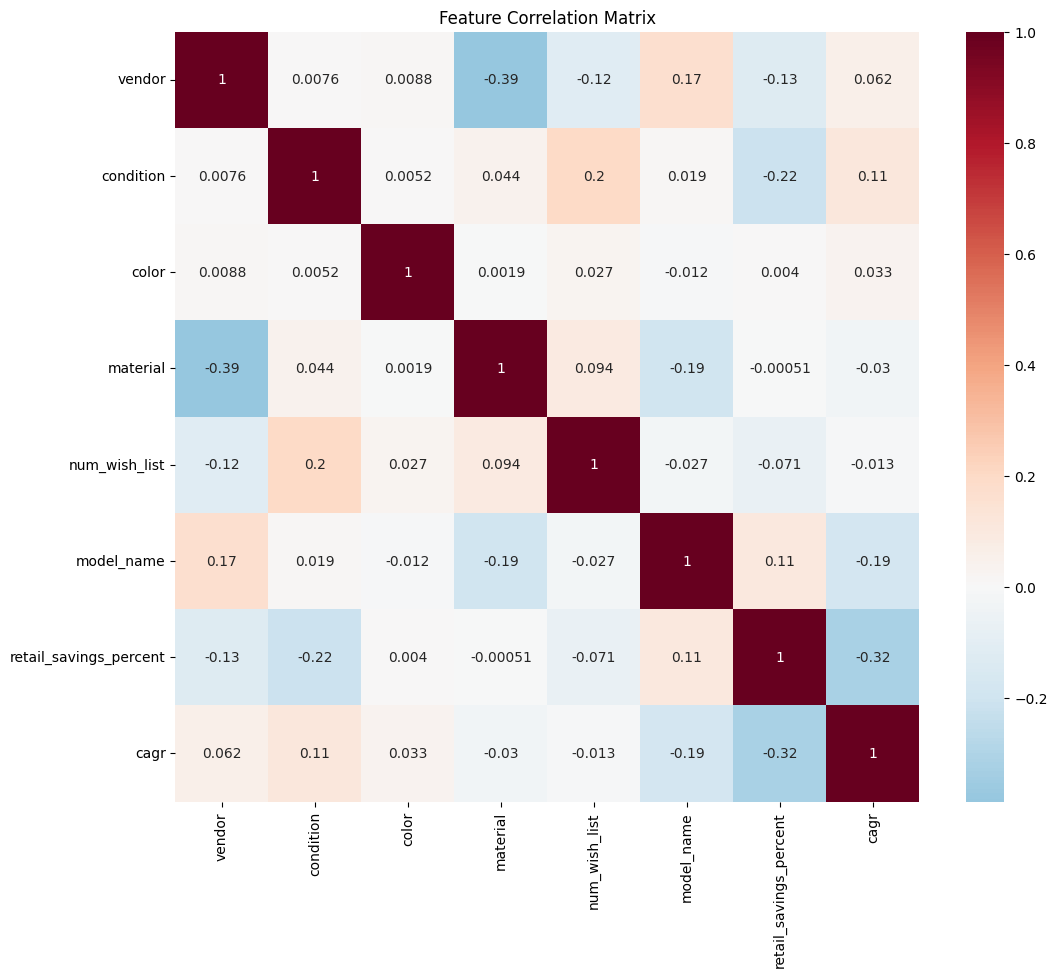

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

#***IDENTIY CORRELATIONS***
#Step 1: Create the correlation matrix
matrix = df_model.corr()

#Step 2: Plot correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, cmap='RdBu_r', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [27]:
#***Remove highly correlated variables and reduce multi-collinearity

#Step1: Remove features highly correlated with CAGR (>0.9)
df_model.drop(columns=['retail_savings_percent'], inplace=True)

#Step 2: Reduce multi-collinearity (>0.3)
df_model.drop(columns=['material'], inplace=True)
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10735 entries, 12705845018927 to 15896031363375
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vendor         10735 non-null  int64  
 1   condition      10735 non-null  int64  
 2   color          10735 non-null  int64  
 3   num_wish_list  10735 non-null  int64  
 4   model_name     10735 non-null  int64  
 5   cagr           10735 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 587.1 KB
None


In [ ]:
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score

#***PRELIMINARY MODEL CREATION***
#print(df_model.info())

#Step 1: Split features and target
#X = df_model.drop('cagr', axis=1)
#y = df_model['cagr']

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=222)

#Step 2: Train the Model (Using our discussed 'Goldilocks' setup)
#model = RandomForestRegressor(n_estimators=10, max_depth=10, min_samples_leaf=50, random_state=222)
#model.fit(X_train, y_train)

#Step 3: Accuracy Check
#y_pred = model.predict(X_test)
#print(f"R-Squared Score: {r2_score(y_test, y_pred):.4f}")
#print(f"RMSE (Error): {mse(y_test, y_pred)**(1/2):.4f}")

#importances = pd.Series(model.feature_importances_, index=X.columns)
#importances.sort_values().plot(kind='barh', color='royalblue', edgecolor='black')
#plt.title('WIP Feature Importance: What Drives CAGR?')
#plt.show()

#print(importances)


In [28]:
#***Optimize hyperparameters***

import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score

param_grid = {
    'n_estimators': [10,25,50,75],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [50, 75, 80],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=222),
    param_grid=param_grid, scoring='r2', cv = 5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")



NameError: name 'X_train' is not defined

In [29]:
#***CREATE OPTIMIZED MODEL***
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score

#Step 1: Split features and target
X = df_model.drop('cagr', axis=1)
y = df_model['cagr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=222)

#Step 2: Train the Model Using Optimized Hyperarameters
model = RandomForestRegressor(n_estimators=75, max_depth=15, min_samples_leaf=50, random_state=222)
model.fit(X_train, y_train)

#Step 3: Accuracy Check
y_pred = model.predict(X_test)
print(f"R-Squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE (Error): {mse(y_test, y_pred)**(1/2):.4f}")

R-Squared Score: 0.9106
RMSE (Error): 5.7840


In [ ]:

***OBJECTIVE FINDINGS***


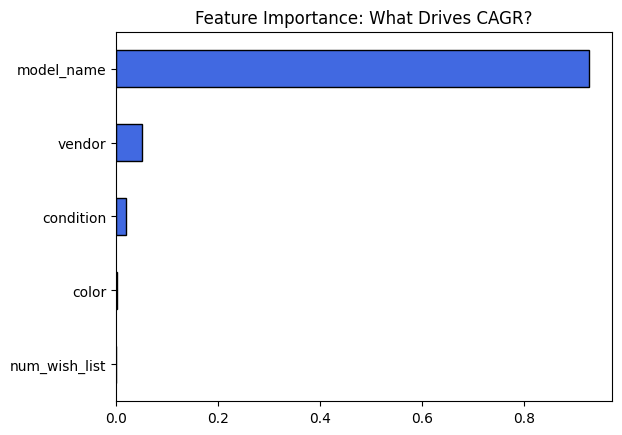

vendor           0.051223
condition        0.018871
color            0.002235
num_wish_list    0.000541
model_name       0.927130
dtype: float64


In [30]:
#1) What handbag features are most important in driving CAGR?
import seaborn as sns
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='royalblue', edgecolor='black')
plt.title('Feature Importance: What Drives CAGR?')
plt.show()
print(importances)


In [31]:
#2) Which bags have the highest Predicted CAGR?

# Create a unique list of bags from your data
unique_bags = df_model.drop(columns='cagr')

# Predict CAGR for all and sort by top 10
unique_bags['Predicted_CAGR'] = model.predict(unique_bags[X.columns])
average_cagr = unique_bags.groupby(['vendor','model_name'],as_index=False).mean()
top_performers = average_cagr.sort_values(by='Predicted_CAGR', ascending=False).head(10)

#Reverse for readability by swapping values with categories
top_10 = top_performers.copy()

for col in ['vendor', 'model_name', 'color', 'material']:
    if col in top_10.columns:
        # Use the specific encoder we saved for this column to turn numbers back to words
        top_10[col] = encoders[col].inverse_transform(top_10[col].astype(int))

#Final results for models with the highest predicted CAGR
print(top_10[['vendor', 'model_name','Predicted_CAGR']])


           vendor model_name  Predicted_CAGR
9          Chanel  Chanel 25       80.000000
33         Hermes     Birkin        1.257915
38         Hermes      Kelly        0.393220
35         Hermes  Constance       -0.028099
54  Louis Vuitton     Speedy       -0.166732
48  Louis Vuitton    Keepall       -0.360244
36         Hermes     Garden       -0.434723
39  Louis Vuitton       Alma       -0.462084
37         Hermes     Herbag       -0.488381
21         Chanel     Wallet       -0.506648


In [32]:
# 3) Given a certain bag, what is is predicted to be in the future?
import pandas as pd

#Create hypothetical bag
hypothetical_bag = {
    'vendor': 'Hermes',
    'condition': 'New',
    'color': 'Black',
    'num_wish_list': 1000,
    'model_name': 'Kelly'
}

#Encode values
encoded_bag = {
    'vendor': [encoders['vendor'].transform([hypothetical_bag['vendor']])[0]],
    'condition': [condition_map[hypothetical_bag['condition']]],
    'color': [encoders['color'].transform([hypothetical_bag['color']])[0]],
    'num_wish_list': [hypothetical_bag['num_wish_list']],
    'model_name': [encoders['model_name'].transform([hypothetical_bag['model_name']])[0]]
}

#Predict
input_df = pd.DataFrame(encoded_bag)
prediction = model.predict(input_df)[0]

print(f"Prediction for {hypothetical_bag['vendor']} {hypothetical_bag['model_name']}: {prediction:.2f}% CAGR (Compounded Annual Growth Rate)")

Prediction for Hermes Kelly: -0.17% CAGR (Compounded Annual Growth Rate)


In [33]:
import joblib

joblib.dump(model, 'bag_cagr_model.pkl')
joblib.dump(encoders, 'encoders_dict.pkl')
joblib.dump(condition_map, 'condition_map.pkl')

print("Files saved: bag_cagr_model.pkl, encoders_dict.pkl, condition_map.pkl")

Files saved: bag_cagr_model.pkl, encoders_dict.pkl, condition_map.pkl


In [34]:
# Create a dictionary where each brand is a key and the value is a list of its models
brand_model_map = df_popular.groupby('vendor')['model_name'].unique().apply(list).to_dict()

# Save this so the dashboard can load it
import joblib
joblib.dump(brand_model_map, 'brand_model_map.pkl')

['brand_model_map.pkl']

In [35]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
matplotlib
seaborn

Writing requirements.txt


In [40]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#Setup & Loading Pickles
st.set_page_config(page_title="Luxury Bag Valuator", layout="wide")

@st.cache_resource
def load_assets():
    model = joblib.load('bag_cagr_model.pkl')
    encoders = joblib.load('encoders_dict.pkl')
    condition_map = joblib.load('condition_map.pkl')
    brand_model_map = joblib.load('brand_model_map.pkl')

    top_bags_data = {
    'model_name': [
        'Chanel 25',
        'Birkin',
        'Kelly',
        'Constance',
        'Speedy'
    ],
    'predicted_cagr': [80.000000, 1.263145, 0.453377, -0.173121, -0.193158]
    }
    top_bags = pd.DataFrame(top_bags_data)

    return model, encoders, condition_map, brand_model_map, top_bags

model, encoders, condition_map, brand_model_map, top_bags = load_assets()

st.title("👜 Luxury Bag Valuation & Market Intelligence")
st.divider()

col1, col2 = st.columns([1, 2], gap="large")

#Column 1: Valuation Engine
with col1:
  st.subheader("📈 Luxury Bag Valuation Engine")
  st.markdown("Select bag features to predict the **Compound Annual Growth Rate (CAGR)**.")

# Valuation Engine Inputs
  with st.container(border=True):
    brand = st.selectbox("Brand / Designer", sorted(list(brand_model_map.keys())))

    available_models = sorted(brand_model_map[brand])
    model_name = st.selectbox("Model", available_models)

    color = st.selectbox("Primary Color", encoders['color'].classes_)

    condition_label = st.selectbox("Item Condition", options=list(condition_map.keys()), index=2)

    hype_status = st.selectbox("Market Status", options=["Classic", "Trending"], index=1)
    hype_map = {"Classic": 100, "Trending": 1000}

    wishlist_val = hype_map[hype_status]

#Valuation Engine Model
    input_df = pd.DataFrame({
        'vendor': [encoders['vendor'].transform([brand])[0]],
        'condition': [condition_map[condition_label]],
        'color': [encoders['color'].transform([color])[0]],
        'num_wish_list': [wishlist_val],
        'model_name': [encoders['model_name'].transform([model_name])[0]]
    })

    prediction = model.predict(input_df)[0]

#Valuation Engine Results
    st.divider()
    st.subheader(f"Predicted Annual Growth for a {brand} {model_name}")
    st.title(f"{prediction:.2f}%")

    if prediction > 10:
        st.success("🔥 Superior Girl Math: Outperforms the S&P 500")
    elif prediction > 0:
        st.info("🌱 Slow Burn: Appreciates with Time")
    else:
        st.warning("✨ Short Term Gratification: Decreases with Time, But Still Cute")

    st.caption(f"Analysis based on a {brand} {model_name} in {condition_label} condition.")

with col2:
    # ROW 1: Feature Importance Chart
    st.subheader("💎 Key Value Drivers")
    st.markdown(
        "Model has the highest impact on value appreciation, followed by brand and condition. "
    )

    feature_names = ['Brand / Designer', 'Condition', 'Primary Color', 'Market Status', 'Model']
    feat_data = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=True)

    # 2. Create the Figure & Axis natively & make background transparent
    fig, ax = plt.subplots(figsize=(6, 2.5))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    # 3. Create Vertical Bar Chart
    bars = ax.barh(
        feat_data['Feature'],
        feat_data['Importance'],
        color="#ba6a36",
        align='center'
    )

    # 4. Update tick park color, set Labels, and axis range
    ax.tick_params(axis='x', colors='white', labelsize=8)
    ax.tick_params(axis='y', colors='white', labelsize=8)

    ax.set_ylabel("Bag Feature", fontsize=10, color='white', fontweight='bold')
    ax.set_xlabel("Importance Score", fontsize=10, color='white', fontweight='bold')
    ax.set_xlim(0, 1)

    # 5. Add Data Labels (Requirement 5)
    for bar in bars:
            width = bar.get_width()
            if width > 0:
                # Place the label inside the bar slightly
                ax.annotate(format(width, '.2f'),
                            (width + 0.015, bar.get_y() + bar.get_height() / 2.),
                            ha='left', va='center',
                            xytext=(0, 0),
                            textcoords='offset points',
                            fontsize=8,
                            color='white',
                            fontweight='bold')

    # Clean up the top and right borders
    for spine in ax.spines.values():
            spine.set_visible(False)

    # REMOVE GRID LINES (Requirement)
    ax.grid(False)

    # 6. Display in Streamlit
    st.pyplot(fig, clear_figure=True)

    st.divider()

    # ROW 2: Top Performers Chart
    st.subheader("🌟 Top 5 Performing Models")
    st.markdown(
        "High performance by Chanel 25s are due to it being recently released (2025). Hermes bags, such as Birkin and Kellys, show positive growth over time."
    )

    # 2. Create the Figure & Axis natively & make background transparent
    fig, ax = plt.subplots(figsize=(6, 2.5))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    # 3. Create Vertical Bar Chart
    bars = ax.bar(
        top_bags['model_name'],
        top_bags['predicted_cagr'],
        color="#e6c8b7",
        align='center'
    )

    # 4. Update tick park color, set labels, and axis range
    ax.tick_params(axis='x', colors='white', labelsize=8)
    ax.tick_params(axis='y', colors='white', labelsize=8)

    ax.set_ylabel("Predicted CAGR (in %)", fontsize=10, color='white', fontweight='bold')
    ax.set_xlabel("Model", fontsize=10, color='white', fontweight='bold')
    ax.set_ylim(-20, 100)

    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)

    # 5. Add data labels
    for bar in bars:
        height = bar.get_height()

        if height >= 0:
            va_direction = 'bottom'
            offset = 5
        else:
            va_direction = 'top'
            offset = -5

        ax.annotate(format(height, '.2f'),
                    (bar.get_x() + bar.get_width() / 2., height),
                    ha='center',
                    va=va_direction,      # Dynamic anchor direction
                    xytext=(0, offset),   # Dynamic pixel offset shift
                    textcoords='offset points',
                    fontsize=8,
                    color='white',
                    fontweight='bold')

    # Clean up the top and right borders
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    # 6. Display in Streamlit
    st.pyplot(fig, clear_figure=True)


Overwriting app.py
